# GC-VTP pipeline smoke test — Danish waters
Same pipeline as the South China Sea version (shelved, not deleted --
see `test_pipeline.ipynb`), rebuilt around DMA's Danish AIS archive.
Run cell by cell.

In [1]:
import sys
import subprocess

print("python executable:", sys.executable)
print("python version:", sys.version)
print()
print("--- loaded modules (if visible from here) ---")
try:
    print(subprocess.run(['bash', '-lc', 'module list'], capture_output=True, text=True).stderr)
except Exception as e:
    print("couldn't check modules from here:", e)

python executable: /usr/bin/python
python version: 3.12.3 (main, Aug 14 2025, 17:47:21) [GCC 13.3.0]

--- loaded modules (if visible from here) ---
environment: line 17: /usr/share/lmod/lmod/libexec/lmod: No such file or directory



In [1]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
import sys
import torch
import numpy as np

sys.path.insert(0, '.')

from mesh import sample_domain_points, build_mesh
from coastline import load_land_polygons, load_ports, DMA_BOUNDS
from ais_ingest import load_dma_ais_csv, resample_to_snapshots, build_snapshot_sequence
from graph_data import build_hetero_snapshot
from model import GCVTP
from losses import energy_score_loss
from cached_attention import KVCache

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device:", torch.cuda.get_device_name(0))

torch.manual_seed(0)
np.random.seed(0)

torch: 2.9.1+cu128
cuda available: True
device: NVIDIA A40


## 1. Coastline + ports (Danish waters)
Requires `data/ne_10m_land/ne_10m_land.shp` and `data/ports_denmark.csv`
staged ahead of time (download on a login node, not a compute node).

In [2]:
bounds = DMA_BOUNDS  # (7.0, 53.5, 16.0, 58.5) -- North Sea/Skagerrak/Kattegat/w. Baltic

land_polygons = load_land_polygons(bounds, natural_earth_path="data/ne_10m_land/ne_10m_land.shp")
ports = load_ports("data/ports_denmark.csv", bounds)

print("land polygons loaded:", len(land_polygons))
print("ports in domain:", len(ports))

pts, land_flags = sample_domain_points(bounds, land_polygons, ports)
mesh_node_features, mesh_edge_index, _ = build_mesh(pts, land_flags, ports)

print("mesh nodes:", mesh_node_features.shape[0])
print("mesh edges:", mesh_edge_index.shape[1])

land polygons loaded: 58
ports in domain: 14
mesh nodes: 5581
mesh edges: 16717


## 1b. Visualize mesh + reference map side by side

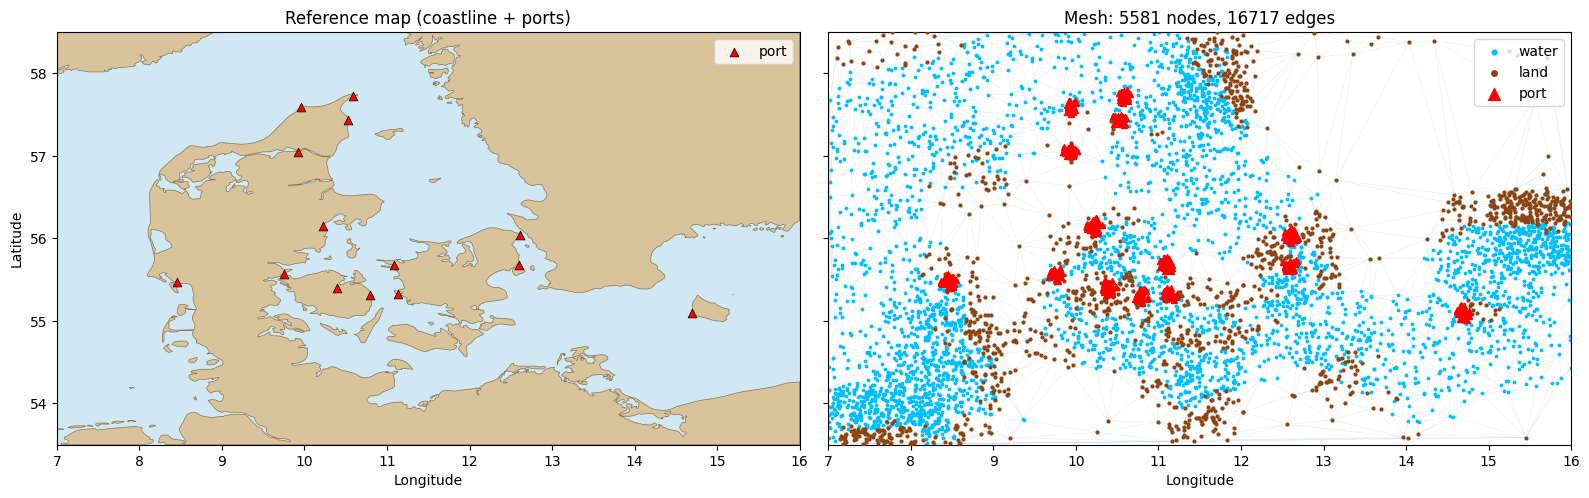

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon


def plot_mesh_with_reference_map(node_features, edge_index, land_polygons, ports,
                                   bounds, max_edges=15000, figsize=(16, 7)):
    lon, lat = node_features[:, 0], node_features[:, 1]
    is_land = node_features[:, 2].astype(bool)
    is_port = node_features[:, 3].astype(bool)
    min_lon, min_lat, max_lon, max_lat = bounds

    fig, (ax_map, ax_mesh) = plt.subplots(1, 2, figsize=figsize, sharex=True, sharey=True)

    ax_map.set_facecolor('#cfe8f3')
    for poly in land_polygons:
        xs, ys = poly.exterior.xy
        ax_map.add_patch(MplPolygon(list(zip(xs, ys)), facecolor='#d8c39a',
                                     edgecolor='#8a7350', linewidth=0.5, zorder=2))
    port_lons = [p[0] for p in ports]
    port_lats = [p[1] for p in ports]
    ax_map.scatter(port_lons, port_lats, s=40, c='red', marker='^',
                    edgecolor='black', linewidth=0.5, label='port', zorder=3)
    ax_map.set_title('Reference map (coastline + ports)')
    ax_map.set_xlabel('Longitude')
    ax_map.set_ylabel('Latitude')
    ax_map.legend(loc='upper right')

    n_edges = edge_index.shape[1]
    if n_edges > max_edges:
        idx = np.random.default_rng(0).choice(n_edges, size=max_edges, replace=False)
        edges_to_plot = edge_index[:, idx]
    else:
        edges_to_plot = edge_index
    segs_lon = np.stack([lon[edges_to_plot[0]], lon[edges_to_plot[1]]], axis=0)
    segs_lat = np.stack([lat[edges_to_plot[0]], lat[edges_to_plot[1]]], axis=0)
    ax_mesh.plot(segs_lon, segs_lat, color='steelblue', linewidth=0.15, alpha=0.35, zorder=1)

    water_mask = ~is_land & ~is_port
    ax_mesh.scatter(lon[water_mask], lat[water_mask], s=3, c='deepskyblue', label='water', zorder=2)
    ax_mesh.scatter(lon[is_land], lat[is_land], s=4, c='saddlebrown', label='land', zorder=3)
    ax_mesh.scatter(lon[is_port], lat[is_port], s=18, c='red', marker='^', label='port', zorder=4)
    ax_mesh.set_title(f'Mesh: {node_features.shape[0]} nodes, {n_edges} edges')
    ax_mesh.set_xlabel('Longitude')
    ax_mesh.legend(loc='upper right', markerscale=2)

    for ax in (ax_map, ax_mesh):
        ax.set_xlim(min_lon, max_lon)
        ax.set_ylim(min_lat, max_lat)
        ax.set_aspect('equal')

    fig.tight_layout()
    return fig


fig = plot_mesh_with_reference_map(mesh_node_features, mesh_edge_index, land_polygons, ports, bounds)
plt.show()

## 2. Real DMA AIS data
Requires a daily CSV from `http://web.ais.dk/aisdata/` staged in
`data/ais/` (e.g. `aisdk-2023-02-15.csv`, downloaded on a login node).

In [4]:
import pandas as pd

ais_path = "data/ais/aisdk-2026-08-25.csv"
start_time = pd.Timestamp("2026-08-25 00:00:00")
end_time = pd.Timestamp("2026-08-25 23:59:59")

ais_df = load_dma_ais_csv(ais_path, bounds, start_time, end_time)
print("AIS records in window:", len(ais_df))
print("unique vessels:", ais_df['mmsi'].nunique())

ais_snapshots = resample_to_snapshots(ais_df, interval_minutes=15)
print("timestamps with data:", len(ais_snapshots))

mmsi_counts = ais_df['mmsi'].value_counts()
print("top vessels by ping count:\n", mmsi_counts.head(10))

AIS records in window: 29204133
unique vessels: 7866
timestamps with data: 96
top vessels by ping count:
 mmsi
235108534    94167
422031200    74830
219022903    73691
305643000    73156
351887000    71604
259490000    67870
219705000    64297
219023648    62677
219007781    62368
636018326    61757
Name: count, dtype: int64


In [5]:
ego_mmsi = mmsi_counts.index[0]  # swap to a specific MMSI once you've picked one

context_snapshots, ego_idx_per_step = build_snapshot_sequence(
    ais_snapshots, mesh_node_features, mesh_edge_index, ego_mmsi
)
print(f"built {len(context_snapshots)} snapshots for vessel {ego_mmsi}")

if len(context_snapshots) < 8:  # need seq_len + future_len at minimum
    print("WARNING: not enough timesteps for this vessel — pick a different ego_mmsi above")

built 96 snapshots for vessel 235108534


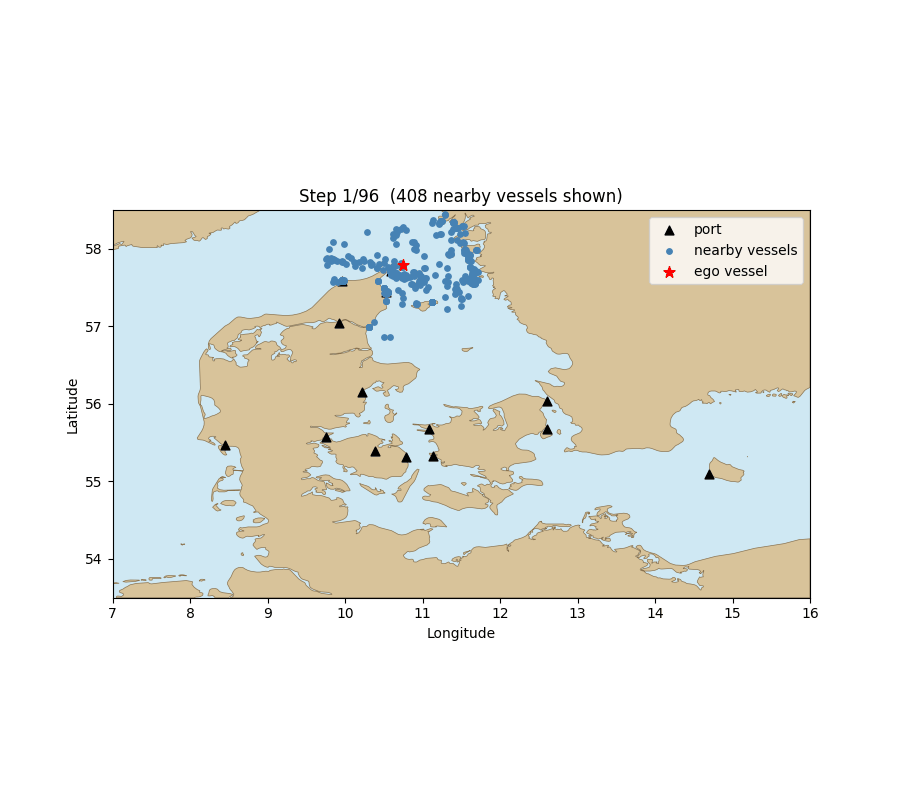

In [6]:
import matplotlib.animation as animation
from IPython.display import Image as IPImage


def animate_vessels(context_snapshots, land_polygons, ports, bounds,
                     nearby_radius_deg=1.0, interval_ms=400, figsize=(9, 8),
                     out_path='vessels.gif'):
    """
    Renders vessel positions frame-by-frame over the coastline as an
    animated GIF. The ego vessel is highlighted in red with a fading trail;
    other vessels within `nearby_radius_deg` of the ego vessel are shown in
    blue (real Danish-waters snapshots can have thousands of vessels, so
    plotting all of them every frame would be dense and slow -- this keeps
    the animation focused on traffic actually relevant to the ego vessel).

    The ego vessel's index is looked up fresh from each snapshot's
    ego_mask rather than assumed constant -- its position within a
    snapshot's vessel list shifts over time as which vessels are present
    changes, so a single fixed index would silently highlight the wrong
    vessel partway through the animation.
    """
    min_lon, min_lat, max_lon, max_lat = bounds
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_facecolor('#cfe8f3')
    for poly in land_polygons:
        xs, ys = poly.exterior.xy
        ax.add_patch(MplPolygon(list(zip(xs, ys)), facecolor='#d8c39a',
                                 edgecolor='#8a7350', linewidth=0.5, zorder=1))
    port_lons = [p[0] for p in ports]
    port_lats = [p[1] for p in ports]
    ax.scatter(port_lons, port_lats, s=40, c='black', marker='^',
               label='port', zorder=2)

    ax.set_xlim(min_lon, max_lon)
    ax.set_ylim(min_lat, max_lat)
    ax.set_aspect('equal')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    other_scatter = ax.scatter([], [], s=15, c='steelblue', label='nearby vessels', zorder=3)
    ego_scatter = ax.scatter([], [], s=70, c='red', marker='*', label='ego vessel', zorder=5)
    ego_trail, = ax.plot([], [], c='red', linewidth=1, alpha=0.5, zorder=4)
    title = ax.set_title('')
    ax.legend(loc='upper right')

    ego_lon_hist, ego_lat_hist = [], []

    def update(frame):
        snap = context_snapshots[frame]
        vx = snap['vessel'].x.cpu().numpy()
        ego_i = snap['vessel'].ego_mask.nonzero()[0].item()

        lon, lat = vx[:, 0], vx[:, 1]
        ego_lon, ego_lat = lon[ego_i], lat[ego_i]

        dist = np.sqrt((lon - ego_lon) ** 2 + (lat - ego_lat) ** 2)
        nearby_mask = (dist <= nearby_radius_deg)
        nearby_mask[ego_i] = False  # ego drawn separately

        other_scatter.set_offsets(np.column_stack([lon[nearby_mask], lat[nearby_mask]]))
        ego_scatter.set_offsets(np.column_stack([[ego_lon], [ego_lat]]))

        ego_lon_hist.append(ego_lon)
        ego_lat_hist.append(ego_lat)
        ego_trail.set_data(ego_lon_hist, ego_lat_hist)

        title.set_text(f'Step {frame + 1}/{len(context_snapshots)}  '
                        f'({nearby_mask.sum()} nearby vessels shown)')
        return other_scatter, ego_scatter, ego_trail, title

    anim = animation.FuncAnimation(
        fig, update, frames=len(context_snapshots), interval=interval_ms, blit=False
    )
    anim.save(out_path, writer='pillow', fps=1000 / interval_ms)
    plt.close(fig)
    return out_path


gif_path = animate_vessels(context_snapshots, land_polygons, ports, bounds, out_path='vessels.gif')
IPImage(filename=gif_path)

## 3. Model forward pass + energy score loss

In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

seq_len, future_len = 4, 4
train_snapshots = context_snapshots[:seq_len]
train_ego_idx = ego_idx_per_step[:seq_len]

model = GCVTP(mesh_in=4, vessel_in=8, hidden=64, future_len=future_len,
              n_heads=4, n_layers=3, max_cache_len=64).to(device)
model.train()

train_snapshots_dev = [d.to(device) for d in train_snapshots]
goal_xy = torch.full((1, 2), float('nan'), device=device)

samples = model(train_snapshots_dev, train_ego_idx, goal_xy, n_samples=16, training=True)
print("samples shape:", samples.shape)

# real target: the ego vessel's actual next `future_len` positions
target_positions = []
for t in range(seq_len, seq_len + future_len):
    ego_i = ego_idx_per_step[t]
    target_positions.append(context_snapshots[t]['vessel'].x[ego_i, :2])
target = torch.stack(target_positions, dim=0).unsqueeze(0).to(device)

loss = energy_score_loss(samples, target)
print("energy score loss:", loss.item())

loss.backward()
grad_norms = [p.grad.norm().item() for p in model.parameters() if p.grad is not None]
print("params with gradients:", len(grad_norms))
print("any NaN grads:", any(np.isnan(g) for g in grad_norms))

samples shape: torch.Size([1, 16, 4, 2])
energy score loss: 234.04470825195312
params with gradients: 68
any NaN grads: False


# Train

In [8]:
#from ais_ingest import select_ego_vessels
from graph_data import VesselSequenceDataset
from torch.utils.data import ConcatDataset, DataLoader

from ais_ingest import select_ego_vessels_stratified

good_vessels = select_ego_vessels_stratified(
    ais_df, min_pings=40, sog_threshold_knots=2.0, n_underway=15, n_stationary=15
)
print(good_vessels['regime'].value_counts())
print(good_vessels.head(10))
print(f"selected {len(good_vessels)} ego vessels out of {ais_df['mmsi'].nunique()} total")
print(good_vessels.head(10))

seq_len, future_len = 4, 4
datasets = []
for ego_mmsi in good_vessels.index:
    snaps, ego_steps = build_snapshot_sequence(ais_snapshots, mesh_node_features, mesh_edge_index, ego_mmsi)
    ds = VesselSequenceDataset(snaps, ego_steps, seq_len=seq_len, future_len=future_len)
    if len(ds) > 0:
        datasets.append(ds)

combined = ConcatDataset(datasets)
print(f"total training windows across {len(datasets)} vessels: {len(combined)}")

regime
underway      15
stationary    15
Name: count, dtype: int64
           n_pings  median_sog               t_min               t_max  \
mmsi                                                                     
219028021    10122         2.2 2026-08-25 00:00:10 2026-08-25 23:59:51   
219021871      211         3.2 2026-08-25 13:47:49 2026-08-25 15:02:16   
211451740     1517         5.0 2026-08-25 09:23:08 2026-08-25 15:23:56   
211365870     1516         3.4 2026-08-25 09:02:22 2026-08-25 13:00:30   
265027640      275         2.8 2026-08-25 12:38:23 2026-08-25 15:46:46   
277391000     1966         6.8 2026-08-25 00:23:28 2026-08-25 23:59:56   
219000159     4095         8.0 2026-08-25 12:56:52 2026-08-25 19:06:54   
219015914       94         3.6 2026-08-25 09:42:19 2026-08-25 13:05:20   
211528300      391         3.1 2026-08-25 07:01:28 2026-08-25 10:42:33   
305814000     2178        10.6 2026-08-25 18:01:16 2026-08-25 23:59:56   

           span_sec  median_ping_interval_se

In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

seq_len, future_len = 4, 4
datasets = []
for ego_mmsi in good_vessels.index:
    snaps, ego_steps = build_snapshot_sequence(ais_snapshots, mesh_node_features, mesh_edge_index, ego_mmsi)
    snaps = [d.to(device) for d in snaps]  # move ONCE per vessel, before windowing --
                                            # never call .to(device) again after this point
    ds = VesselSequenceDataset(snaps, ego_steps, seq_len=seq_len, future_len=future_len)
    if len(ds) > 0:
        datasets.append(ds)

combined = ConcatDataset(datasets)
print(f"total training windows across {len(datasets)} vessels: {len(combined)}")


def collate_single(batch):
    return batch[0]


loader = DataLoader(combined, batch_size=1, shuffle=True, collate_fn=collate_single)

model = GCVTP(mesh_in=4, vessel_in=8, hidden=64, future_len=future_len,
              n_heads=4, n_layers=3, max_cache_len=64).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-4)
goal_xy = torch.full((1, 2), float('nan'), device=device)

total training windows across 27 vessels: 903


In [10]:
all_deltas = []
for ctx, target in combined:
    ego_idx_this_window = [d['vessel'].ego_mask.nonzero()[0].item() for d in ctx]
    last_ctx_pos = ctx[-1]['vessel'].x[ego_idx_this_window[-1], :2]
    all_deltas.append((target - last_ctx_pos.unsqueeze(0)).cpu())  # move to cpu before collecting

all_deltas = torch.cat(all_deltas, dim=0)
norm_scale = all_deltas.std().item()
print(f"delta normalization scale: {norm_scale:.5f} degrees")

delta normalization scale: 0.04067 degrees


In [11]:
model.train()
n_epochs = 20
checkpoint_path = 'checkpoint.pt'

for epoch in range(n_epochs):
    total_loss = 0.0
    for ctx, target in loader:
        ego_idx_this_window = [d['vessel'].ego_mask.nonzero()[0].item() for d in ctx]
        last_ctx_pos = ctx[-1]['vessel'].x[ego_idx_this_window[-1], :2]
        target_delta = (target - last_ctx_pos.unsqueeze(0)) / norm_scale  # normalized
        samples = model(ctx, ego_idx_this_window, goal_xy, n_samples=16, training=True)
        loss = energy_score_loss(samples, target_delta.unsqueeze(0))
        opt.zero_grad()
        loss.backward()
        opt.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(combined)
    print(f"epoch {epoch}: avg loss = {avg_loss:.4f}")

    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': opt.state_dict(),
        'norm_scale': norm_scale,
        'epoch': epoch,
        'avg_loss': avg_loss,
    }, checkpoint_path)

epoch 0: avg loss = 2.5246
epoch 1: avg loss = 2.4724
epoch 2: avg loss = 2.4318
epoch 3: avg loss = 2.2419
epoch 4: avg loss = 2.0988
epoch 5: avg loss = 1.5909
epoch 6: avg loss = 1.3664
epoch 7: avg loss = 1.2959
epoch 8: avg loss = 1.1765
epoch 9: avg loss = 1.1571
epoch 10: avg loss = 1.0720
epoch 11: avg loss = 1.0795
epoch 12: avg loss = 1.0488
epoch 13: avg loss = 1.0063
epoch 14: avg loss = 1.0122
epoch 15: avg loss = 0.9785
epoch 16: avg loss = 0.9516
epoch 17: avg loss = 0.9385
epoch 18: avg loss = 0.9115
epoch 19: avg loss = 0.9064


correlation: 0.691


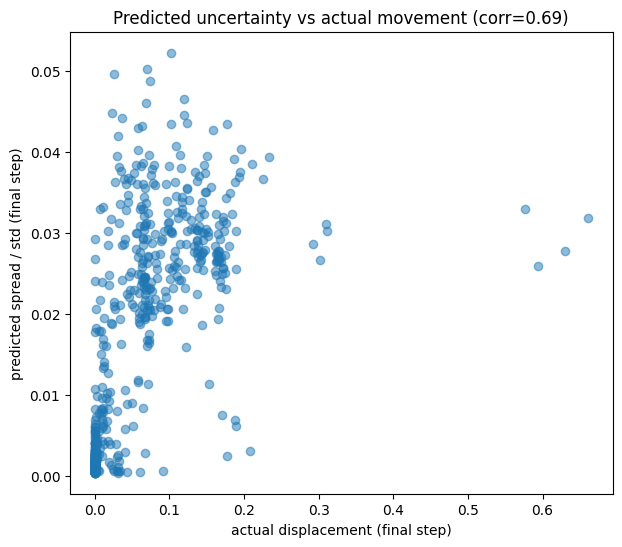

In [23]:
model.eval()
actual_displacements, predicted_spreads = [], []
with torch.no_grad():
    for i in range(len(combined)):
        ctx, target = combined[i]
        ego_idx_this_window = [d['vessel'].ego_mask.nonzero()[0].item() for d in ctx]
        last_ctx_pos = ctx[-1]['vessel'].x[ego_idx_this_window[-1], :2]
        samples = model(ctx, ego_idx_this_window, goal_xy, n_samples=32, training=False)
        samples_real = samples * norm_scale  # convert back to real degree-scale distances
        pred_spread = samples_real[0, :, -1, :].std(dim=0).norm().item()
        actual_disp = (target[-1] - last_ctx_pos).norm().item()
        actual_displacements.append(actual_disp)
        predicted_spreads.append(pred_spread)

actual_displacements = np.array(actual_displacements)
predicted_spreads = np.array(predicted_spreads)
corr = np.corrcoef(actual_displacements, predicted_spreads)[0, 1]
print(f"correlation: {corr:.3f}")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(actual_displacements, predicted_spreads, alpha=0.5)
ax.set_xlabel('actual displacement (final step)')
ax.set_ylabel('predicted spread / std (final step)')
ax.set_title(f'Predicted uncertainty vs actual movement (corr={corr:.2f})')
plt.show()

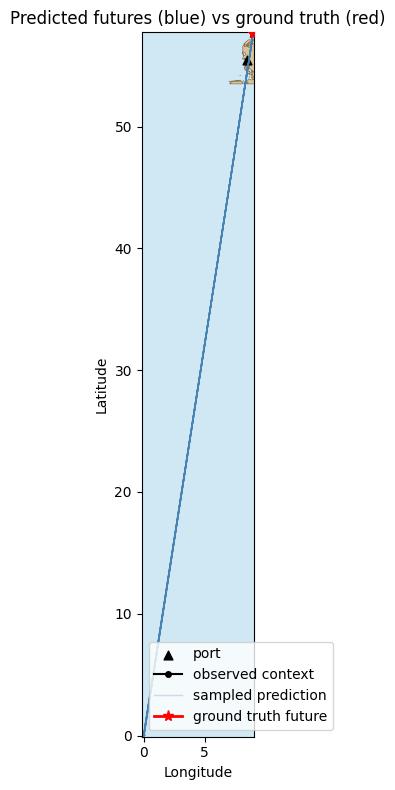

In [13]:
def plot_prediction_vs_truth(ctx, target, samples, land_polygons, ports, bounds,
                               ego_idx_this_window, figsize=(9, 8)):
    """
    Plots one prediction window: the ego vessel's observed context path,
    all FGN-sampled predicted futures (faint blue), and the real
    ground-truth future path (bold red) -- lets you visually check
    whether predictions are sane rather than trusting the loss number
    alone.
    """
    min_lon, min_lat, max_lon, max_lat = bounds
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_facecolor('#cfe8f3')
    for poly in land_polygons:
        xs, ys = poly.exterior.xy
        ax.add_patch(MplPolygon(list(zip(xs, ys)), facecolor='#d8c39a',
                                 edgecolor='#8a7350', linewidth=0.5, zorder=1))
    port_lons = [p[0] for p in ports]
    port_lats = [p[1] for p in ports]
    ax.scatter(port_lons, port_lats, s=40, c='black', marker='^', label='port', zorder=2)

    context_xy = np.array([
        d['vessel'].x[ego_idx_this_window[t], :2].cpu().numpy()
        for t, d in enumerate(ctx)
    ])
    ax.plot(context_xy[:, 0], context_xy[:, 1], c='black', marker='o',
            markersize=4, linewidth=1.5, label='observed context', zorder=3)

    samples_np = samples[0].detach().cpu().numpy()
    for s in range(samples_np.shape[0]):
        full_path = np.vstack([context_xy[-1:], samples_np[s]])
        ax.plot(full_path[:, 0], full_path[:, 1], c='steelblue', alpha=0.25,
                linewidth=1, zorder=2, label='sampled prediction' if s == 0 else None)

    truth_np = target.cpu().numpy()
    truth_full = np.vstack([context_xy[-1:], truth_np])
    ax.plot(truth_full[:, 0], truth_full[:, 1], c='red', marker='*', markersize=8,
            linewidth=2, label='ground truth future', zorder=4)

    all_xy = np.vstack([context_xy, samples_np.reshape(-1, 2), truth_np])
    pad = 0.05
    ax.set_xlim(all_xy[:, 0].min() - pad, all_xy[:, 0].max() + pad)
    ax.set_ylim(all_xy[:, 1].min() - pad, all_xy[:, 1].max() + pad)
    ax.set_aspect('equal')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title('Predicted futures (blue) vs ground truth (red)')
    ax.legend(loc='best')
    fig.tight_layout()
    return fig


# after your training loop finishes:
model.eval()
ctx, target = combined[0]  # or any index -- try a few different windows
ego_idx_this_window = [d['vessel'].ego_mask.nonzero()[0].item() for d in ctx]
with torch.no_grad():
    samples = model(ctx, ego_idx_this_window, goal_xy, n_samples=32, training=False)

fig = plot_prediction_vs_truth(ctx, target, samples, land_polygons, ports, bounds, ego_idx_this_window)
plt.show()

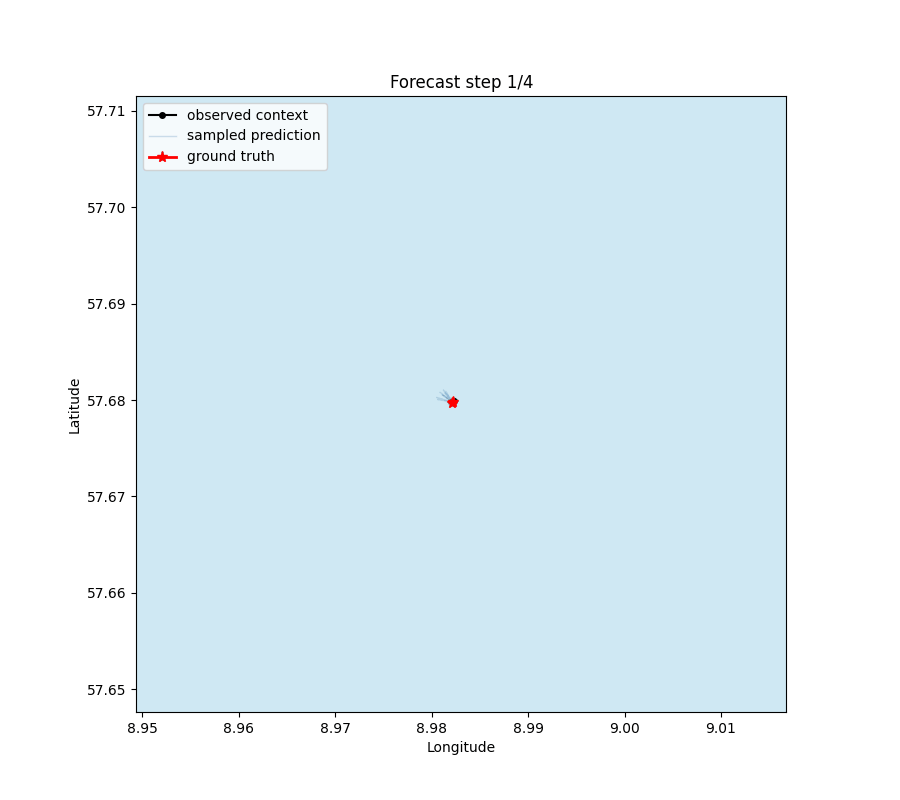

In [25]:
import matplotlib.animation as animation
from IPython.display import Image as IPImage


def animate_prediction_vs_truth(ctx, target, samples_real, land_polygons, ports, bounds,
                                  ego_idx_this_window, interval_ms=600, figsize=(9, 8),
                                  out_path='prediction.gif'):
    """
    Animates one prediction window step by step: observed context (black,
    static), then each future step reveals more of the ground truth (red)
    and the growing cloud of predicted sample trajectories (blue), so you
    can see how predicted uncertainty evolves across the horizon relative
    to what actually happened.
    """
    min_lon, min_lat, max_lon, max_lat = bounds
    context_xy = np.array([
        d['vessel'].x[ego_idx_this_window[t], :2].cpu().numpy()
        for t, d in enumerate(ctx)
    ])
    samples_np = samples_real[0].detach().cpu().numpy()
    truth_np = target.cpu().numpy()
    future_len = truth_np.shape[0]

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_facecolor('#cfe8f3')
    for poly in land_polygons:
        xs, ys = poly.exterior.xy
        ax.add_patch(MplPolygon(list(zip(xs, ys)), facecolor='#d8c39a',
                                 edgecolor='#8a7350', linewidth=0.5, zorder=1))
    ax.scatter([p[0] for p in ports], [p[1] for p in ports], s=40, c='black', marker='^', zorder=2)
    ax.plot(context_xy[:, 0], context_xy[:, 1], c='black', marker='o', markersize=4,
            linewidth=1.5, label='observed context', zorder=3)

    all_xy = np.vstack([context_xy, samples_np.reshape(-1, 2), truth_np])
    padding = 0.03
    ax.set_xlim(all_xy[:, 0].min() - padding, all_xy[:, 0].max() + padding)
    ax.set_ylim(all_xy[:, 1].min() - padding, all_xy[:, 1].max() + padding)
    ax.set_aspect('equal')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    title = ax.set_title('')

    sample_lines = [ax.plot([], [], c='steelblue', alpha=0.25, linewidth=1,
                             label='sampled prediction' if s == 0 else None, zorder=2)[0]
                     for s in range(samples_np.shape[0])]
    truth_line, = ax.plot([], [], c='red', marker='*', markersize=8, linewidth=2,
                           label='ground truth', zorder=4)
    ax.legend(loc='upper left')

    def update(frame):
        step = frame + 1
        for s, line in enumerate(sample_lines):
            path = np.vstack([context_xy[-1:], samples_np[s, :step]])
            line.set_data(path[:, 0], path[:, 1])
        truth_path = np.vstack([context_xy[-1:], truth_np[:step]])
        truth_line.set_data(truth_path[:, 0], truth_path[:, 1])
        title.set_text(f'Forecast step {step}/{future_len}')
        return sample_lines + [truth_line, title]

    anim = animation.FuncAnimation(fig, update, frames=future_len, interval=interval_ms, blit=False)
    anim.save(out_path, writer='pillow', fps=1000 / interval_ms)
    plt.close(fig)
    return out_path


model.eval()
ctx, target = combined[0]  # try a few different indices
ego_idx_this_window = [d['vessel'].ego_mask.nonzero()[0].item() for d in ctx]
last_ctx_pos = ctx[-1]['vessel'].x[ego_idx_this_window[-1], :2]
with torch.no_grad():
    samples = model(ctx, ego_idx_this_window, goal_xy, n_samples=24, training=False)
    samples_real = samples * norm_scale + last_ctx_pos

gif_path = animate_prediction_vs_truth(ctx, target, samples_real, land_polygons, ports, bounds,
                                         ego_idx_this_window, out_path='prediction.gif')
IPImage(filename=gif_path)

In [26]:
import numpy as np

def haversine_km(lon1, lat1, lon2, lat2):
    R = 6371.0
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1; dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

samples_np = samples_real[0].cpu().numpy()  # (n_samples, future_len, 2)
final_step = samples_np[:, -1, :]  # (n_samples, 2) -- lon,lat at last forecast step
center = final_step.mean(axis=0)
spreads_km = [haversine_km(center[0], center[1], p[0], p[1]) for p in final_step]

print(f"predicted spread at final step: mean={np.mean(spreads_km):.3f}km, max={np.max(spreads_km):.3f}km")
print(f"ground truth actual displacement: {haversine_km(last_ctx_pos[0].item(), last_ctx_pos[1].item(), target[-1,0].item(), target[-1,1].item()):.3f}km")

predicted spread at final step: mean=0.109km, max=0.332km
ground truth actual displacement: 0.027km


In [27]:
# find a window with real, substantial displacement
for i in range(len(combined)):
    ctx_i, target_i = combined[i]
    ego_idx_i = [d['vessel'].ego_mask.nonzero()[0].item() for d in ctx_i]
    last_pos_i = ctx_i[-1]['vessel'].x[ego_idx_i[-1], :2]
    disp_km = haversine_km(last_pos_i[0].item(), last_pos_i[1].item(), target_i[-1,0].item(), target_i[-1,1].item())
    if disp_km > 3.0:  # pick a clearly-moving example
        print(f"window {i}: actual displacement = {disp_km:.2f}km")
        break

ctx, target = combined[i]
ego_idx_this_window = [d['vessel'].ego_mask.nonzero()[0].item() for d in ctx]
last_ctx_pos = ctx[-1]['vessel'].x[ego_idx_this_window[-1], :2]
with torch.no_grad():
    samples = model(ctx, ego_idx_this_window, goal_xy, n_samples=24, training=False)
    samples_real = samples * norm_scale + last_ctx_pos

samples_np = samples_real[0].cpu().numpy()
final_step = samples_np[:, -1, :]
center = final_step.mean(axis=0)
spreads_km = [haversine_km(center[0], center[1], p[0], p[1]) for p in final_step]
print(f"predicted spread: mean={np.mean(spreads_km):.3f}km, max={np.max(spreads_km):.3f}km")
print(f"ground truth displacement: {disp_km:.3f}km")

window 11: actual displacement = 4.29km
predicted spread: mean=0.244km, max=0.828km
ground truth displacement: 4.294km


In [28]:
final_step = samples_np[:, -1, :]        # (n_samples, 2) -- predicted final positions
mean_pred = final_step.mean(axis=0)      # model's average predicted position
true_final = target[-1].cpu().numpy()

error_km = haversine_km(mean_pred[0], mean_pred[1], true_final[0], true_final[1])
print(f"prediction error (mean predicted vs actual): {error_km:.3f}km")
print(f"for reference, actual displacement was: {disp_km:.3f}km")

prediction error (mean predicted vs actual): 4.132km
for reference, actual displacement was: 4.294km


In [29]:
model.eval()
trivial_baseline_errors = []
model_errors = []
displacements = []

with torch.no_grad():
    for i in range(len(combined)):
        ctx_i, target_i = combined[i]
        ego_idx_i = [d['vessel'].ego_mask.nonzero()[0].item() for d in ctx_i]
        last_pos_i = ctx_i[-1]['vessel'].x[ego_idx_i[-1], :2]
        true_final = target_i[-1].cpu().numpy()
        last_pos_np = last_pos_i.cpu().numpy()

        disp_km = haversine_km(last_pos_np[0], last_pos_np[1], true_final[0], true_final[1])
        if disp_km < 1.0:  # focus on genuinely moving windows only
            continue

        samples = model(ctx_i, ego_idx_i, goal_xy, n_samples=24, training=False)
        samples_real = samples * norm_scale + last_pos_i
        mean_pred = samples_real[0, :, -1, :].mean(dim=0).cpu().numpy()

        model_err = haversine_km(mean_pred[0], mean_pred[1], true_final[0], true_final[1])
        trivial_err = disp_km  # "no movement" baseline error equals the actual displacement

        displacements.append(disp_km)
        model_errors.append(model_err)
        trivial_baseline_errors.append(trivial_err)

displacements = np.array(displacements)
model_errors = np.array(model_errors)
trivial_baseline_errors = np.array(trivial_baseline_errors)

print(f"n moving windows (>1km): {len(displacements)}")
print(f"model mean error: {model_errors.mean():.3f}km")
print(f"trivial 'no movement' baseline mean error: {trivial_baseline_errors.mean():.3f}km")
print(f"model beats trivial baseline on {100*(model_errors < trivial_baseline_errors).mean():.1f}% of windows")

n moving windows (>1km): 357
model mean error: 3.234km
trivial 'no movement' baseline mean error: 9.075km
model beats trivial baseline on 88.0% of windows


# Extra Research

## 4. KV-cache correctness check

In [16]:
for t, snap in enumerate(train_snapshots_dev):
    n_vessels = snap['vessel'].x.shape[0]
    vx = snap['vessel'].x
    ego_from_mask = snap['vessel'].ego_mask.nonzero()[0].item()
    ego_from_list = train_ego_idx[t]
    print(f"t={t}: n_vessels={n_vessels}, ego_idx (list)={ego_from_list}, "
          f"ego_idx (mask)={ego_from_mask}, match={ego_from_list == ego_from_mask}")
    print(f"  lon range: [{vx[:,0].min().item():.3f}, {vx[:,0].max().item():.3f}]")
    print(f"  lat range: [{vx[:,1].min().item():.3f}, {vx[:,1].max().item():.3f}]")
    print(f"  sog range: [{vx[:,2].min().item():.3f}, {vx[:,2].max().item():.3f}]")
    print(f"  cog range: [{vx[:,3].min().item():.3f}, {vx[:,3].max().item():.3f}]")
    print(f"  any inf: {torch.isinf(vx).any().item()}, any nan: {torch.isnan(vx).any().item()}")

t=0: n_vessels=2404, ego_idx (list)=1427, ego_idx (mask)=1427, match=True
  lon range: [7.050, 16.000]
  lat range: [53.646, 58.495]
  sog range: [0.000, 32.900]
  cog range: [0.000, 359.800]
  any inf: False, any nan: False
t=1: n_vessels=2542, ego_idx (list)=1504, ego_idx (mask)=1504, match=True
  lon range: [7.001, 15.999]
  lat range: [53.598, 58.495]
  sog range: [0.000, 21.500]
  cog range: [0.000, 359.900]
  any inf: False, any nan: False
t=2: n_vessels=2568, ego_idx (list)=1517, ego_idx (mask)=1517, match=True
  lon range: [7.001, 15.943]
  lat range: [53.598, 58.499]
  sog range: [0.000, 21.200]
  cog range: [0.000, 359.700]
  any inf: False, any nan: False
t=3: n_vessels=2552, ego_idx (list)=1488, ego_idx (mask)=1488, match=True
  lon range: [7.048, 15.999]
  lat range: [53.598, 58.478]
  sog range: [0.000, 26.900]
  cog range: [0.000, 359.900]
  any inf: False, any nan: False


In [17]:
model.eval()
with torch.no_grad():
    out1 = model.gnn(train_snapshots_dev[0])
    out2 = model.gnn(train_snapshots_dev[0])  # same exact object, called twice

diff = (out1 - out2).abs()
print("max abs diff between two identical GNN calls on GPU:", diff.max().item())

max abs diff between two identical GNN calls on GPU: 0.000958561897277832


In [18]:
import torch
torch.use_deterministic_algorithms(True, warn_only=True)

model.eval()
with torch.no_grad():
    full_context = model.encode_context(train_snapshots_dev, train_ego_idx)
    cache = KVCache(model.n_layers)
    step_out = None
    for t, snap in enumerate(train_snapshots_dev):
        step_out = model.rollout_step(snap, cache, position=t)

diff = (full_context - step_out).abs()
print("max abs diff (deterministic mode):", diff.max().item())
torch.use_deterministic_algorithms(False)  # turn back off for normal training speed

max abs diff (deterministic mode): 9.5367431640625e-07


In [19]:
model.eval()
with torch.no_grad():
    full_context = model.encode_context(train_snapshots_dev, train_ego_idx)

    cache = KVCache(model.n_layers)
    step_out = None
    for t, snap in enumerate(train_snapshots_dev):
        step_out = model.rollout_step(snap, cache, position=t)

diff = (full_context - step_out).abs()
print("max abs diff:", diff.max().item())
print("allclose (atol=1e-5):", torch.allclose(full_context, step_out, atol=1e-5))

max abs diff: 9.5367431640625e-07
allclose (atol=1e-5): True


In [20]:
rel_diff = diff / (full_context.abs() + 1e-8)
print("max relative diff:", rel_diff.max().item())
print("full_context scale (mean abs):", full_context.abs().mean().item())

max relative diff: 4.412360340211308e-06
full_context scale (mean abs): 3.2760415077209473


# Mesh Density

displacement per 15min step (km): median=0.01, mean=1.21, p90=4.24
open-water mesh edge length (km): median=6.04, mean=8.24
near-port mesh edge length (km): median=4.56, mean=5.78


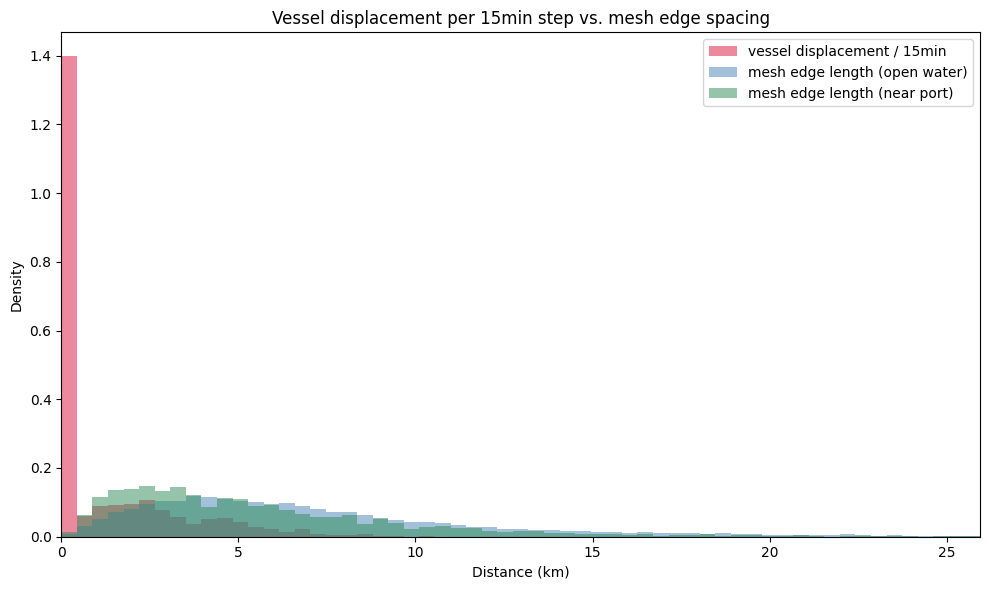

In [21]:
def haversine_km(lon1, lat1, lon2, lat2):
    R = 6371.0
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


def compute_vessel_displacements_km(ais_snapshots, max_vessels=500, rng_seed=0):
    """
    For each vessel, computes great-circle distance between consecutive
    resampled timestamps it appears in (only truly consecutive bins --
    a gap means the vessel was absent for a step, which isn't a real
    per-step displacement and would inflate the distribution misleadingly).
    """
    timestamps = sorted(ais_snapshots.keys())
    ts_index = {ts: i for i, ts in enumerate(timestamps)}

    tracks = {}
    for ts in timestamps:
        for mmsi, state in ais_snapshots[ts].items():
            tracks.setdefault(mmsi, []).append((ts_index[ts], state[0], state[1]))

    mmsi_list = list(tracks.keys())
    if len(mmsi_list) > max_vessels:
        rng = np.random.default_rng(rng_seed)
        mmsi_list = rng.choice(mmsi_list, size=max_vessels, replace=False)

    displacements = []
    for mmsi in mmsi_list:
        pts = sorted(tracks[mmsi], key=lambda p: p[0])
        for (i0, lon0, lat0), (i1, lon1, lat1) in zip(pts[:-1], pts[1:]):
            if i1 - i0 == 1:
                displacements.append(haversine_km(lon0, lat0, lon1, lat1))
    return np.array(displacements)


def compute_mesh_edge_lengths_km(mesh_node_features, mesh_edge_index, ports,
                                   near_port_radius_deg=0.3):
    lon, lat = mesh_node_features[:, 0], mesh_node_features[:, 1]
    src, dst = mesh_edge_index[0], mesh_edge_index[1]
    lengths = haversine_km(lon[src], lat[src], lon[dst], lat[dst])

    port_lons = np.array([p[0] for p in ports])
    port_lats = np.array([p[1] for p in ports])

    def near_any_port(lons, lats):
        d2 = (lons[:, None] - port_lons[None, :]) ** 2 + (lats[:, None] - port_lats[None, :]) ** 2
        return np.sqrt(d2).min(axis=1) <= near_port_radius_deg

    src_near = near_any_port(lon[src], lat[src])
    dst_near = near_any_port(lon[dst], lat[dst])
    near_port_mask = src_near | dst_near

    return lengths[near_port_mask], lengths[~near_port_mask]


def plot_displacement_vs_mesh(displacements_km, near_port_edges_km, open_water_edges_km,
                                interval_minutes, figsize=(10, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    combined = np.concatenate([displacements_km, near_port_edges_km, open_water_edges_km])
    x_max = np.percentile(combined, 99)
    bins = np.linspace(0, x_max, 60)
    ax.hist(displacements_km, bins=bins, alpha=0.5, label=f'vessel displacement / {interval_minutes}min', color='crimson', density=True)
    ax.hist(open_water_edges_km, bins=bins, alpha=0.5, label='mesh edge length (open water)', color='steelblue', density=True)
    ax.hist(near_port_edges_km, bins=bins, alpha=0.5, label='mesh edge length (near port)', color='seagreen', density=True)
    ax.set_xlim(0, x_max)
    ax.set_xlabel('Distance (km)')
    ax.set_ylabel('Density')
    ax.set_title(f'Vessel displacement per {interval_minutes}min step vs. mesh edge spacing')
    ax.legend()
    fig.tight_layout()
    return fig


displacements = compute_vessel_displacements_km(ais_snapshots)
near_port_edges, open_water_edges = compute_mesh_edge_lengths_km(mesh_node_features, mesh_edge_index, ports)

print(f"displacement per 15min step (km): median={np.median(displacements):.2f}, "
      f"mean={np.mean(displacements):.2f}, p90={np.percentile(displacements, 90):.2f}")
print(f"open-water mesh edge length (km): median={np.median(open_water_edges):.2f}, "
      f"mean={np.mean(open_water_edges):.2f}")
print(f"near-port mesh edge length (km): median={np.median(near_port_edges):.2f}, "
      f"mean={np.mean(near_port_edges):.2f}")

fig = plot_displacement_vs_mesh(displacements, near_port_edges, open_water_edges, interval_minutes=15)
plt.show()

underway vessels  -- n=17129, median=2.554km, mean=3.059km, p90=5.791km
stationary vessels -- n=25615, median=0.002km, mean=0.050km, p90=0.025km


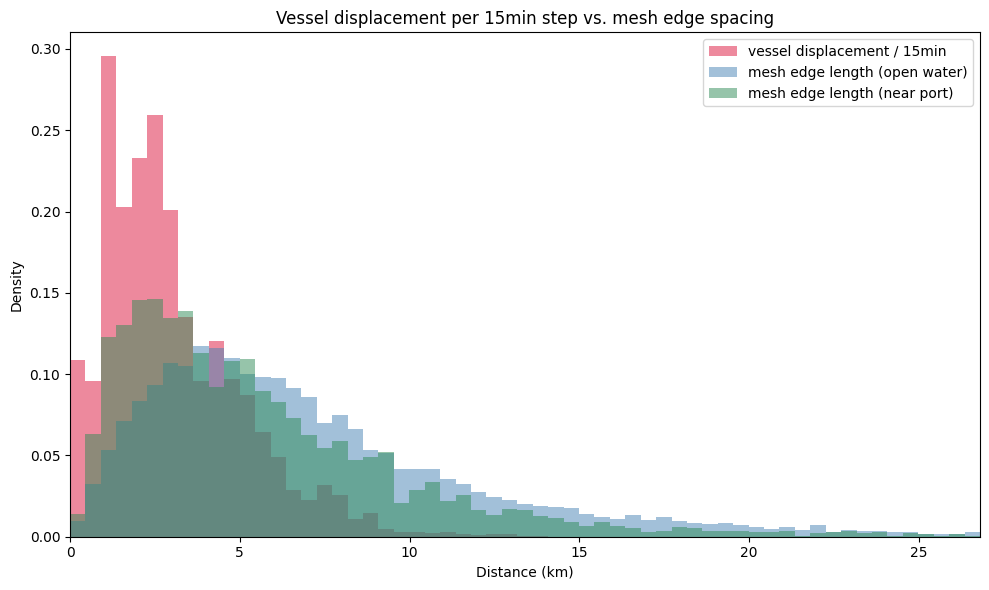

In [22]:
def compute_vessel_displacements_km_by_sog(ais_snapshots, sog_threshold_knots=2.0, max_vessels=1000, rng_seed=0):
    """
    Splits per-step displacement by whether the vessel was underway
    (SOG >= threshold) or effectively stationary (anchored, moored,
    drifting) at that step -- a single blended distribution hides these
    two very different populations.
    """
    timestamps = sorted(ais_snapshots.keys())
    ts_index = {ts: i for i, ts in enumerate(timestamps)}
    tracks = {}
    for ts in timestamps:
        for mmsi, state in ais_snapshots[ts].items():
            tracks.setdefault(mmsi, []).append((ts_index[ts], state[0], state[1], state[2]))

    mmsi_list = list(tracks.keys())
    if len(mmsi_list) > max_vessels:
        rng = np.random.default_rng(rng_seed)
        mmsi_list = rng.choice(mmsi_list, size=max_vessels, replace=False)

    underway, stationary = [], []
    for mmsi in mmsi_list:
        pts = sorted(tracks[mmsi], key=lambda p: p[0])
        for (i0, lon0, lat0, sog0), (i1, lon1, lat1, sog1) in zip(pts[:-1], pts[1:]):
            if i1 - i0 == 1:
                d = haversine_km(lon0, lat0, lon1, lat1)
                avg_sog = (sog0 + sog1) / 2
                (underway if avg_sog >= sog_threshold_knots else stationary).append(d)
    return np.array(underway), np.array(stationary)


underway, stationary = compute_vessel_displacements_km_by_sog(ais_snapshots)
print(f"underway vessels  -- n={len(underway)}, median={np.median(underway):.3f}km, "
      f"mean={np.mean(underway):.3f}km, p90={np.percentile(underway,90):.3f}km")
print(f"stationary vessels -- n={len(stationary)}, median={np.median(stationary):.3f}km, "
      f"mean={np.mean(stationary):.3f}km, p90={np.percentile(stationary,90):.3f}km")

fig = plot_displacement_vs_mesh(underway, near_port_edges, open_water_edges, interval_minutes=15)
plt.show()